# imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from tqdm import tqdm
import os
import polars as pl
from towbintools.foundation.file_handling import get_dir_filemap, add_dir_to_experiment_filemap, read_filemap
from joblib import Parallel, delayed
import bottleneck as bn

In [ ]:
experiment_dir = "/mnt/towbin.data/shared/spsalmon/20251023_115945_091_ZIVA_60x_397_405_yap_dynamics"
output_dir = "./plots/20251023_115945_091_ZIVA_60x_397_405_yap_dynamics/"
os.makedirs(output_dir, exist_ok=True)
raw_dir = os.path.join(experiment_dir, "raw_stacks")
raw_dir_name = os.path.basename(raw_dir)
analysis_dir = os.path.join(experiment_dir, "analysis_stacks")
report_dir = os.path.join(analysis_dir, "report")

stacks_filemap = get_dir_filemap(raw_dir)
stacks_filemap = stacks_filemap.rename({"ImagePath": raw_dir_name})
mask_dir = os.path.join(analysis_dir, "ch2_seg_cellpose")
stacks_filemap = add_dir_to_experiment_filemap(stacks_filemap, mask_dir, os.path.basename(mask_dir))

classification_dir = None
measurements_dir = os.path.join(analysis_dir, "ch1_cellpose_final_measurements")
stacks_filemap = add_dir_to_experiment_filemap(stacks_filemap, measurements_dir, os.path.basename(measurements_dir))

stacks_filemap = stacks_filemap.filter((pl.col(os.path.basename(mask_dir)) != "") & (pl.col(os.path.basename(measurements_dir)) != ""))

In [ ]:
experiment_filemap_path = os.path.join(experiment_dir, "analysis", "report", "analysis_filemap_annotated.csv")
experiment_filemap = read_filemap(experiment_filemap_path)
experiment_filemap = experiment_filemap.join(stacks_filemap, on=['Time', 'Point'], how='left')
# remove all the columns with "_at" in their name, as these are not needed for the plotting
experiment_filemap = experiment_filemap.drop([col for col in experiment_filemap.columns if "_at" in col])
# experiment_filemap = experiment_filemap.filter(pl.col("ch1_cellpose_measurements").is_not_null())

experiment_filemap = experiment_filemap.with_columns((pl.col("ExperimentTime") / 3600).alias("ExperimentTimeHours"))

In [ ]:
import yaml

def build_conditions(conditions_yaml):
    """
    Process a conditions YAML file structured in a factorized way. Refer to the documentation for the expected format.
    The function will return a list of dictionaries, each representing a condition with its parameters.

    Parameters:
        conditions_yaml (str or dict): Path to the YAML file or a dictionary containing the conditions.
    Returns:
        list: A list of dictionaries, each representing a condition with its parameters.
    Raises:
        ValueError: If the conditions YAML file is not structured correctly.
    """
    if isinstance(conditions_yaml, str):
        with open(conditions_yaml) as file:
            conditions_dict = yaml.safe_load(file)
            file.close()
    elif isinstance(conditions_yaml, dict):
        conditions_dict = conditions_yaml

    conditions = []
    condition_id = 0

    for condition in conditions_dict["conditions"]:
        condition = {
            key: [val] if not isinstance(val, list) else val
            for key, val in condition.items()
        }

        lengths = {len(val) for val in condition.values()}
        if len(lengths) > 2 or (len(lengths) == 2 and 1 not in lengths):
            raise ValueError(
                "All lists in the condition must have the same length or be of length 1."
            )

        max_length = max(lengths)
        for i in range(max_length):
            condition_dict = {
                key: val[0] if len(val) == 1 else val[i]
                for key, val in condition.items()
            }
            condition_dict["condition_id"] = condition_id
            conditions.append(condition_dict)
            condition_id += 1

    return conditions


def _add_conditions_to_filemap(experiment_filemap, conditions):
    """Add conditions to experiment filemap based on point ranges or pad values."""
    if "Pad" in experiment_filemap.columns:
        new_columns = experiment_filemap.select(pl.col("Point"), pl.col("Pad"))
    else:
        new_columns = experiment_filemap.select(pl.col("Point"))
    for condition in conditions:
        # Get condition rows mask
        if "point_range" in condition:
            point_range = condition["point_range"]
            # handle both single range and list of ranges
            if isinstance(point_range[0], list):
                # multiple point ranges - build expressions list
                mask_exprs = [
                    (pl.col("Point") >= pr[0]) & (pl.col("Point") <= pr[1])
                    for pr in point_range
                ]
                # Combine with or operator
                condition_mask = mask_exprs[0]
                for expr in mask_exprs[1:]:
                    condition_mask = condition_mask | expr
            else:
                # single point range
                condition_mask = (pl.col("Point") >= point_range[0]) & (
                    pl.col("Point") <= point_range[1]
                )
            filter_key = "point_range"
        elif "pad" in condition:
            pad = condition["pad"]
            condition_mask = pl.col("Pad") == pad
            filter_key = "pad"
        else:
            print(
                "Condition does not contain 'point_range' or 'pad' key, impossible to add condition to filemap, skipping."
            )
            continue

        # Extract the condition attributes to add (excluding the filter key)
        conditions_to_add = {k: v for k, v in condition.items() if k != filter_key}

        column_ops = []
        for key, val in conditions_to_add.items():
            # For new columns, add with null values first if needed
            if key not in new_columns.columns:
                new_columns = new_columns.with_columns(pl.lit(None).alias(key))

            # Build the column operation but don't apply it yet
            column_ops.append(
                pl.when(condition_mask)
                .then(pl.lit(val))
                .otherwise(pl.col(key))
                .alias(key)
            )

        # Add the new columns to the DataFrame
        if column_ops:
            new_columns = new_columns.with_columns(column_ops)

    if "Pad" in new_columns.columns:
        new_columns = new_columns.drop(["Point", "Pad"])
    else:
        new_columns = new_columns.drop(["Point"])

    # Apply the new columns to the experiment filemap
    if not new_columns.is_empty():
        experiment_filemap = experiment_filemap.with_columns(new_columns)

    return experiment_filemap

In [ ]:
condition_id_to_color = {
    0: "#4497E0",
    1: "#124877",
}

new_descriptions = {
    0: "control",
    1: "epidermal growth inhibition",
}

In [ ]:
condition_file = os.path.join(experiment_dir, "doc", "conditions.yaml")
conditions = build_conditions(condition_file)
experiment_filemap = _add_conditions_to_filemap(experiment_filemap, conditions)
experiment_filemap

# can we find out which nuclei present the highest level of yap-1 activity ?

In [32]:
strain = "wBT397"
strain_filemap = experiment_filemap.filter(pl.col("strain") == strain)
strain_filemap = strain_filemap.filter(~pl.col('Ignore'))
strain_filemap = strain_filemap.filter(pl.col("ch1_cellpose_final_measurements").is_not_null())

strain_filemap = strain_filemap.filter((pl.col("HatchTime").is_null()) | (pl.col("Time") > pl.col("HatchTime")))
strain_filemap = strain_filemap.filter((pl.col("M1").is_not_null()) & (pl.col("Time") < pl.col("M1")))
all_nuclei_measurements = []
for row in tqdm(strain_filemap.iter_rows(named=True)):
    try:
        columns = pl.read_csv(row["ch1_cellpose_final_measurements"], n_rows=0).columns
        schema = {col: pl.Float64 for col in columns}
        schema["Z"] = pl.Int64
        schema["Label"] = pl.Int64
        schema["Type"] = pl.Utf8

        nuclei_measurements = pl.read_csv(row["ch1_cellpose_final_measurements"], schema=schema)
        all_nuclei_measurements.append(nuclei_measurements)
    except Exception as e:
        print(f"Failed to read {row['ch1_cellpose_final_measurements']}: {e}")

all_nuclei_measurements = pl.concat(all_nuclei_measurements, how="vertical", )

0it [00:00, ?it/s]

621it [00:01, 361.59it/s]


In [33]:
all_nuclei_measurements

Z,Label,Size,CentroidX,CentroidY,MeanIntensityNucleus,MedianIntensityNucleus,MeanIntensityCytoplasm,MedianIntensityCytoplasm,NucleusCytoplasmRatioMean,NucleusCytoplasmRatioMedian,Type
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
9,1,118.0,301.322034,672.788136,170.40678,170.5,179.754717,178.5,0.947996,0.955182,"""background"""
9,2,80.0,308.875,694.5,135.4875,135.5,174.111111,173.5,0.778167,0.78098,"""epidermis"""
10,3,88.0,250.159091,626.306818,146.704545,149.0,152.947917,153.0,0.95918,0.973856,"""background"""
10,4,100.0,353.67,710.72,159.04,159.0,184.524752,186.0,0.86189,0.854839,"""background"""
12,5,124.0,231.532258,599.241935,112.290323,113.5,139.533333,130.0,0.804756,0.873077,"""background"""
…,…,…,…,…,…,…,…,…,…,…,…
19,141,29.0,356.275862,700.655172,51.896552,49.0,55.111111,52.0,0.941671,0.942308,"""background"""
20,142,147.0,630.693878,316.92517,78.986395,76.0,94.725664,84.0,0.833844,0.904762,"""background"""
20,143,47.0,397.042553,651.446809,83.234043,85.0,85.012658,84.0,0.979078,1.011905,"""background"""


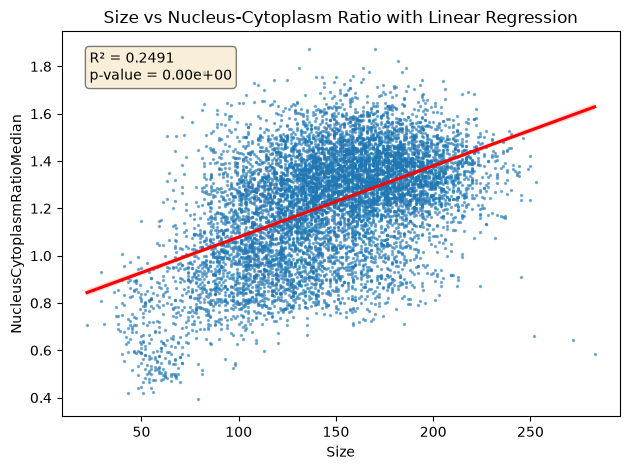

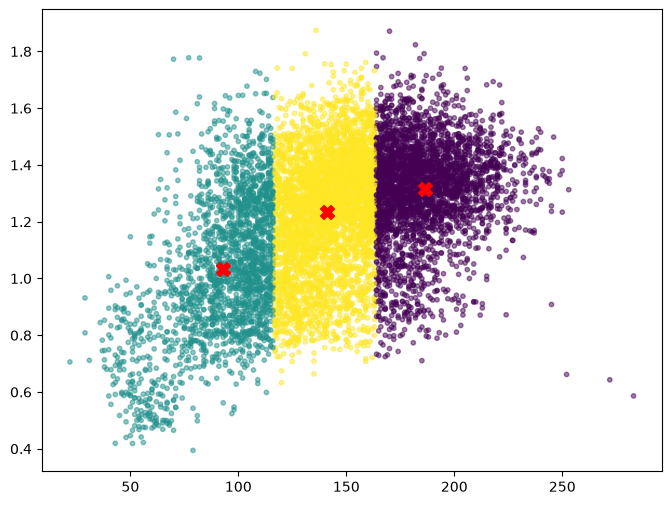

In [189]:
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
epidermis_measurements = all_nuclei_measurements.filter(pl.col("Type") == "epidermis")
# epidermis_measurements = all_nuclei_measurements

# scatterplot of size vs NucleusCytoplasmRatioMedian
fig, ax = plt.subplots()
sns.regplot(data=epidermis_measurements.to_pandas(), x="Size", y="NucleusCytoplasmRatioMedian", 
            scatter_kws={'s': 2, 'alpha': 0.5}, line_kws={'color': 'red'}, ax=ax)
ax.set_xlabel("Size")
ax.set_ylabel("NucleusCytoplasmRatioMedian")
ax.set_title("Size vs Nucleus-Cytoplasm Ratio with Linear Regression")

# Calculate R-squared
x = epidermis_measurements.to_pandas()["Size"].values
y = epidermis_measurements.to_pandas()["NucleusCytoplasmRatioMedian"].values
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2

ax.text(0.05, 0.95, f'R² = {r_squared:.4f}\np-value = {p_value:.2e}', 
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto")
X = epidermis_measurements.select(["Size", "NucleusCytoplasmRatioMedian"]).to_numpy()
kmeans.fit(X)

# plot the clusters
plt.figure(figsize=(8, 6))
# Scatter plot of the data points colored by cluster label
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', s=10, alpha=0.5)
# Plot the cluster centers
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', s=100, marker='X', label='Centroids')

In [144]:
import numpy as np
from scipy.interpolate import UnivariateSpline


def _project_to_polyline(X, C):
    """Project points X (N,2) onto polyline C (M,2).
    Returns arc-length param, foot points, signed distance."""
    seg = np.diff(C, axis=0)                       # (M-1, 2)
    L = np.linalg.norm(seg, axis=1)
    s = np.concatenate([[0.0], np.cumsum(L)])      # arc length of vertices
    denom = np.maximum((seg ** 2).sum(1), 1e-12)

    AX = X[:, None, :] - C[None, :-1, :]           # (N, M-1, 2)
    t = np.clip((AX * seg[None]).sum(-1) / denom[None], 0.0, 1.0)
    foot = C[None, :-1, :] + t[..., None] * seg[None]
    d2 = ((X[:, None, :] - foot) ** 2).sum(-1)

    j = d2.argmin(1)
    i = np.arange(len(X))
    lam = s[j] + t[i, j] * L[j]
    fp = foot[i, j]
    tang = seg[j] / np.maximum(L[j, None], 1e-12)
    v = X - fp
    signed = tang[:, 0] * v[:, 1] - tang[:, 1] * v[:, 0]   # 2D cross product
    return lam, fp, signed


def principal_curve(X, smooth=0.05, n_grid=400, max_iter=25, tol=1e-4, w=None):
    """Hastie-Stuetzle principal curve in 2D.
    smooth: spline smoothing as a fraction of total variance (0.01-0.2 typical)."""
    X = np.asarray(X, float)
    n = len(X)
    mu = X.mean(0)
    Xc = X - mu
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    lam = Xc @ Vt[0]                               # PC1 projection as init
    prev = np.inf

    for _ in range(max_iter):
        order = np.argsort(lam)
        lo, Xo = lam[order], X[order]
        wo = None if w is None else w[order]
        # collapse duplicate parameter values (UnivariateSpline needs strict increase)
        lo = lo + np.linspace(0, 1e-9, n)

        curve = []
        grid = np.linspace(lo[0], lo[-1], n_grid)
        for d in range(X.shape[1]):
            s_d = smooth * n * Xo[:, d].var()
            spl = UnivariateSpline(lo, Xo[:, d], w=wo, s=s_d, k=3)
            curve.append(spl(grid))
        C = np.column_stack(curve)

        lam, fp, _ = _project_to_polyline(X, C)
        mse = np.mean(((X - fp) ** 2).sum(1))
        if abs(prev - mse) < tol * max(mse, 1e-12):
            break
        prev = mse

    lam, fp, signed = _project_to_polyline(X, C)
    return C, lam, fp, signed

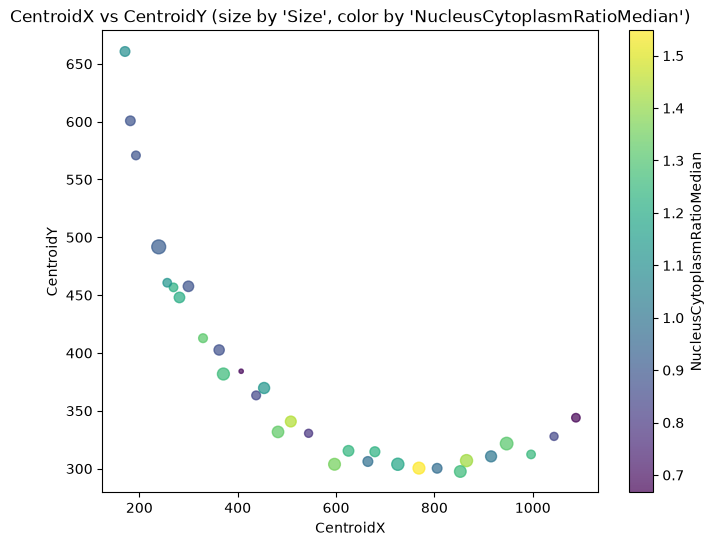

Z,Label,Size,CentroidX,CentroidY,MeanIntensityNucleus,MedianIntensityNucleus,MeanIntensityCytoplasm,MedianIntensityCytoplasm,NucleusCytoplasmRatioMean,NucleusCytoplasmRatioMedian,Type,axial_position,lateral_offset
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64
8,1,101.0,437.514851,363.336634,124.029703,123.0,143.536842,145.0,0.864097,0.848276,"""epidermis""",0.395515,3.351274
9,3,167.0,725.616766,303.784431,187.185629,184.0,158.423729,155.5,1.18155,1.18328,"""epidermis""",0.67243,1.352268
9,4,158.0,596.905063,303.772152,189.487342,183.0,133.974359,135.0,1.414355,1.355556,"""epidermis""",0.553382,-11.324619
8,5,118.0,664.711864,306.169492,131.601695,135.0,143.625,137.5,0.916287,0.981818,"""epidermis""",0.615508,-0.250575
9,6,165.0,865.29697,306.933333,196.915152,197.0,139.693069,139.0,1.409627,1.417266,"""epidermis""",0.8031,1.656876
…,…,…,…,…,…,…,…,…,…,…,…,…,…
9,30,97.0,1087.742268,344.010309,75.731959,74.0,110.726316,111.0,0.683956,0.666667,"""epidermis""",1.0,3.879153
9,31,132.0,281.575758,448.015152,191.401515,194.0,164.5,161.0,1.163535,1.204969,"""epidermis""",0.23008,-7.451189
9,32,97.0,269.484536,456.721649,193.206186,197.0,158.988095,161.5,1.215224,1.219814,"""epidermis""",0.216517,-9.400504


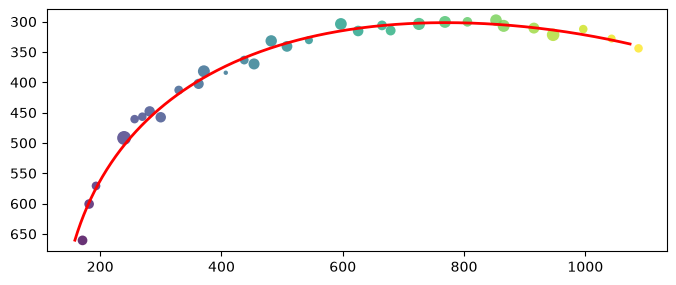

In [188]:
# take a random nuclei measurement
random_row = strain_filemap.sample(n=1)
measurements = pl.read_csv(random_row[0, "ch1_cellpose_final_measurements"])
measurements

measurements = measurements.filter(pl.col("Type") == "epidermis")
centroids = measurements.select(["CentroidX", "CentroidY"]).to_numpy()
# scatter centroidX vs centroidY with point size scaled by "Size"
sizes = measurements["Size"].to_numpy()
if sizes.max() > sizes.min():
    point_sizes = 10 + 90 * (sizes - sizes.min()) / (sizes.max() - sizes.min())
else:
    point_sizes = np.full_like(sizes, 30.0)

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    measurements["CentroidX"],
    measurements["CentroidY"],
    s=point_sizes,
    c=measurements["NucleusCytoplasmRatioMedian"],
    cmap="viridis",
    alpha=0.7,
)
plt.colorbar(sc, label="NucleusCytoplasmRatioMedian")
plt.xlabel("CentroidX")
plt.ylabel("CentroidY")
plt.title("CentroidX vs CentroidY (size by 'Size', color by 'NucleusCytoplasmRatioMedian')")
plt.show()

curve, lam, foot, offset = principal_curve(centroids, smooth=0.25)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(centroids[:, 0], centroids[:, 1], s=point_sizes, c=lam,
           cmap="viridis", alpha=0.8, edgecolor="none")
ax.plot(curve[:, 0], curve[:, 1], "r-", lw=2)
ax.set_aspect("equal")
ax.invert_yaxis()   # image coordinates

measurements = measurements.with_columns(
    pl.Series("axial_position", lam / lam.max()),
    pl.Series("lateral_offset", offset),
)

measurements